# INSS Statistics Homework - Detailed solutions

This notebook solves the five statistics exercises in `Neutrino_School-stats.pdf` / `Neutrino_School-stats.md` using the data organized under the local `data/` folder.

I cite the supplied course material explicitly where it is used. The citations are to file names and slide/section numbers:

- `INSS_LectureStats_I.pdf`, slides 32, 36-38, 41-46: maximum likelihood, $\Delta\mathrm{NLL}$ intervals, profile likelihood, and linear-algebra fitting/covariance.
- `INSS_LectureStats_II.pdf`, slides 3-4, 8-9, 15, 17: profile likelihood for nuisance parameters, extended likelihood, vertical morphing for shape systematics, parameter bounds, and constrained fits/Lagrange multipliers.
- `CourseNotes.pdf`, Sections 20.1-20.2 and 21.1-21.2: matrix least-squares fitting, covariance matrices, elimination of variables, and Lagrange-multiplier constrained fits.

Conventions used throughout:

- Negative log-likelihoods are quoted up to constants that do not depend on fit parameters.
- One-standard-deviation intervals from a one-parameter profile scan use $\Delta\mathrm{NLL}=0.5$, following the asymptotic likelihood discussion in `INSS_LectureStats_I.pdf`, slides 36-38, and the profile-likelihood discussion in `INSS_LectureStats_I.pdf`, slide 42 / `INSS_LectureStats_II.pdf`, slides 3-4.
- Detector strip pitch is $50\,\mu\mathrm{m}=0.005\,\mathrm{cm}$, so I take the measurement uncertainty of a digitized strip center to be $0.005/\sqrt{12}\,\mathrm{cm}$.

Repository data layout used by this version:

- `data/exercise_1/histForMinuitFit_q1.npz`
- `data/exercise_2/file_q2.txt`
- `data/exercise_3/straightTracks.txt`

The original exercise statements and lecture/reference PDFs are kept in `reference_material/`.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, minimize_scalar, brentq

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})

# Expected repository layout:
#
# INSS_2026/
#   INSS_Stats_Detailed_Solutions.ipynb
#   data/
#     exercise_1/histForMinuitFit_q1.npz
#     exercise_2/file_q2.txt
#     exercise_3/straightTracks.txt
#
# Start JupyterLab from the repository root with:
#   cd ~/Repos/INSS_2026
#   jupyter lab

REPO_ROOT = Path.cwd()
DATA_ROOT = REPO_ROOT / "data"
EX1_DIR = DATA_ROOT / "exercise_1"
EX2_DIR = DATA_ROOT / "exercise_2"
EX3_DIR = DATA_ROOT / "exercise_3"

required_files = [
    EX1_DIR / "histForMinuitFit_q1.npz",
    EX2_DIR / "file_q2.txt",
    EX3_DIR / "straightTracks.txt",
]
# file extraction code written with the help of Chat GPT
missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing expected data file(s):\n"
        + "\n".join(missing)
        + "\n\nRun JupyterLab from the repository root, or update REPO_ROOT manually."
    )

print(f"Repository root: {REPO_ROOT}")
print(f"Exercise 1 data: {EX1_DIR}")
print(f"Exercise 2 data: {EX2_DIR}")
print(f"Exercise 3 data: {EX3_DIR}")


Matplotlib is building the font cache; this may take a moment.


Repository root: /Users/ali/Repos/INSS_2026
Exercise 1 data: /Users/ali/Repos/INSS_2026/data/exercise_1
Exercise 2 data: /Users/ali/Repos/INSS_2026/data/exercise_2
Exercise 3 data: /Users/ali/Repos/INSS_2026/data/exercise_3


## Exercise 1 - Extended $S+B$ template fit with and without a shape systematic

### Statistical model

The exercise asks for an **extended** binned likelihood, because the total event count is not treated as fixed. This follows `INSS_LectureStats_II.pdf`, slide 8, where the lecture distinguishes the fixed-composition fit from the extended $S+B$ case.

For bin $i$, I use

$$
\mu_i(S,B,\alpha)=S\,s_i+B\,b_i(\alpha),
$$

where $s_i$ is the normalized signal template, $b_i(\alpha)$ is the normalized background template after morphing, $S$ is the signal yield, and $B$ is the background yield. The extended binned negative log-likelihood, dropping the data-only factorial constants, is

$$
\mathrm{NLL}(S,B,\alpha)=\sum_i \left[\mu_i-d_i\ln\mu_i\right]+\frac{\alpha^2}{2}.
$$

The Gaussian constraint $\alpha^2/2$ treats the background-shape systematic as a nuisance with a standard-normal prior. This is the vertical morphing/nuisance-parameter approach described in `INSS_LectureStats_II.pdf`, slide 9. The nuisance is profiled in the fit and in the $S$ scan, following `INSS_LectureStats_II.pdf`, slides 3-4.

### Morphing choice

The file provides a central background histogram `b_pdf` and two $\pm 1\sigma$ variations. I use a piecewise vertical morphing rule:

$$
b_i(\alpha)=
\begin{cases}
 b_i^{0}+\alpha(b_i^{+}-b_i^{0}) & \alpha\ge 0,\\
 b_i^{0}+(-\alpha)(b_i^{-}-b_i^{0}) & \alpha<0.
\end{cases}
$$

After morphing, I clip tiny negative numerical values if extrapolation goes too far and renormalize the template to sum to one. To turn the shape systematic off, I fix $\alpha=0$, exactly as suggested in the exercise hint.

Number of bins: 18
Total observed data events: 725
Template normalizations: signal=1.000000, background=1.000000


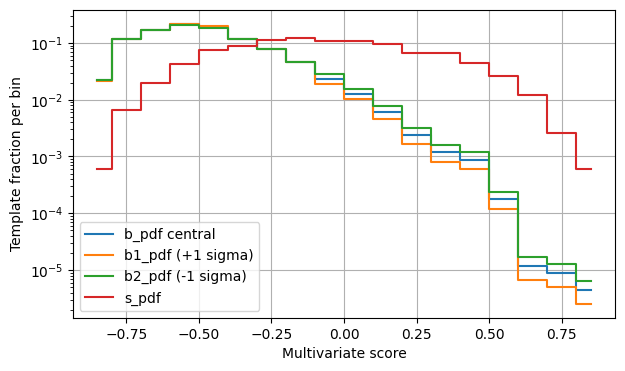

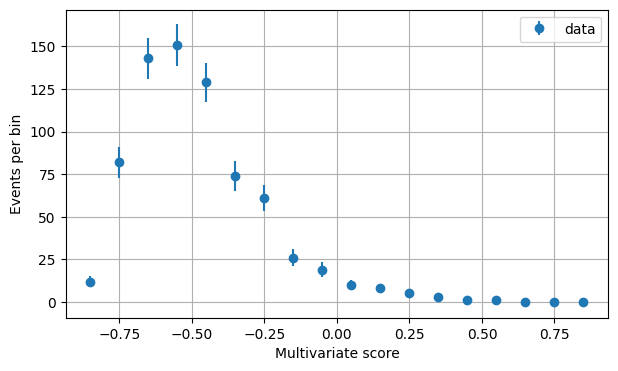

In [2]:
npz = np.load(EX1_DIR / "histForMinuitFit_q1.npz")
b_pdf = npz["b_pdf"].astype(float)
b1_pdf = npz["b1_pdf"].astype(float)   # treated as +1 sigma
b2_pdf = npz["b2_pdf"].astype(float)   # treated as -1 sigma
s_pdf = npz["s_pdf"].astype(float)
data = npz["d"].astype(float)
bin_centers = npz["binCen"]
bin_edges = npz["binEdges"]

# Defensively normalize all templates.
b_pdf /= b_pdf.sum()
b1_pdf /= b1_pdf.sum()
b2_pdf /= b2_pdf.sum()
s_pdf /= s_pdf.sum()

print(f"Number of bins: {len(data)}")
print(f"Total observed data events: {data.sum():.0f}")
print(f"Template normalizations: signal={s_pdf.sum():.6f}, background={b_pdf.sum():.6f}")

fig, ax1 = plt.subplots()
ax1.step(bin_centers, b_pdf, where="mid", label="b_pdf central")
ax1.step(bin_centers, b1_pdf, where="mid", label="b1_pdf (+1 sigma)")
ax1.step(bin_centers, b2_pdf, where="mid", label="b2_pdf (-1 sigma)")
ax1.step(bin_centers, s_pdf, where="mid", label="s_pdf")
ax1.set_yscale("log")
ax1.set_xlabel("Multivariate score")
ax1.set_ylabel("Template fraction per bin")
ax1.legend()
plt.show()

fig, ax = plt.subplots()
ax.errorbar(bin_centers, data, yerr=np.sqrt(np.maximum(data, 1)), fmt="o", label="data")
ax.set_xlabel("Multivariate score")
ax.set_ylabel("Events per bin")
ax.legend()
plt.show()

In [3]:
def morph_background(alpha):
    """Piecewise vertical morphing of the background template."""
    alpha = float(alpha)
    if alpha >= 0:
        h = b_pdf + alpha * (b1_pdf - b_pdf)
    else:
        h = b_pdf + (-alpha) * (b2_pdf - b_pdf)
    h = np.clip(h, 1e-12, None)
    return h / h.sum()


def nll_ex1(params, include_shape=True, fixed_S=None):
    """Extended binned Poisson NLL for Exercise 1."""
    if fixed_S is None:
        if include_shape:
            S, B, alpha = params
        else:
            S, B = params
            alpha = 0.0
    else:
        S = fixed_S
        if include_shape:
            B, alpha = params
        else:
            (B,) = params
            alpha = 0.0

    if S < 0 or B < 0:
        return 1e100

    mu = S * s_pdf + B * morph_background(alpha)
    if np.any(mu <= 0) or not np.all(np.isfinite(mu)):
        return 1e100

    out = np.sum(mu - data * np.log(mu))
    if include_shape:
        out += 0.5 * alpha**2
    return float(out)


def fit_ex1(include_shape):
    if include_shape:
        x0 = np.array([50.0, max(data.sum() - 50.0, 1.0), 0.0])
        bounds = [(0, None), (0, None), (-5, 5)]
    else:
        x0 = np.array([50.0, max(data.sum() - 50.0, 1.0)])
        bounds = [(0, None), (0, None)]
    return minimize(lambda p: nll_ex1(p, include_shape), x0, method="L-BFGS-B", bounds=bounds)

fit_no_shape = fit_ex1(include_shape=False)
fit_with_shape = fit_ex1(include_shape=True)

print("Without shape systematic:")
print(f"  converged = {fit_no_shape.success}")
print(f"  S_hat = {fit_no_shape.x[0]:.3f}")
print(f"  B_hat = {fit_no_shape.x[1]:.3f}")
print(f"  NLL_min = {fit_no_shape.fun:.3f}")

print("\nWith profiled shape systematic:")
print(f"  converged = {fit_with_shape.success}")
print(f"  S_hat = {fit_with_shape.x[0]:.3f}")
print(f"  B_hat = {fit_with_shape.x[1]:.3f}")
print(f"  alpha_hat = {fit_with_shape.x[2]:.3f}")
print(f"  NLL_min = {fit_with_shape.fun:.3f}")

Without shape systematic:
  converged = True
  S_hat = 23.506
  B_hat = 701.469
  NLL_min = -2515.384

With profiled shape systematic:
  converged = True
  S_hat = 19.923
  B_hat = 705.093
  alpha_hat = -0.413
  NLL_min = -2515.537


Profile scan intervals using Delta NLL = 0.5:
  no shape:   S = 23.51 +10.94 -9.50
  with shape: S = 19.92 +12.61 -11.02


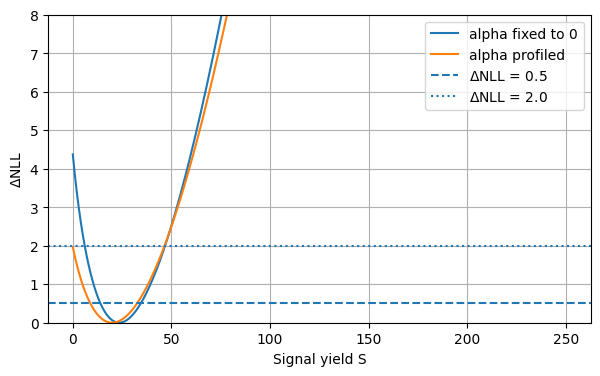

In [4]:
def profile_scan_ex1(include_shape, S_values):
    """Profile all nuisance parameters at fixed S."""
    nll_values = []
    nuisance_values = []

    if include_shape:
        x_prev = fit_with_shape.x[1:].copy()
        bounds = [(0, None), (-5, 5)]
    else:
        x_prev = np.array([fit_no_shape.x[1]])
        bounds = [(0, None)]

    for S in S_values:
        res = minimize(
            lambda p: nll_ex1(p, include_shape=include_shape, fixed_S=S),
            x_prev,
            method="L-BFGS-B",
            bounds=bounds,
        )
        nll_values.append(res.fun)
        nuisance_values.append(res.x.copy())
        x_prev = res.x

    return np.array(nll_values), np.array(nuisance_values)


def interval_from_delta_nll(x, delta, level=0.5):
    """Linear interpolation of the left/right crossings of a Delta-NLL curve."""
    i_min = int(np.argmin(delta))
    x_hat = x[i_min]
    left = np.nan
    right = np.nan

    for i in range(i_min, 0, -1):
        if (delta[i] - level) * (delta[i - 1] - level) <= 0:
            left = np.interp(level, [delta[i], delta[i - 1]], [x[i], x[i - 1]])
            break
    for i in range(i_min, len(x) - 1):
        if (delta[i] - level) * (delta[i + 1] - level) <= 0:
            right = np.interp(level, [delta[i], delta[i + 1]], [x[i], x[i + 1]])
            break
    return x_hat, left, right

S_values = np.linspace(0, 250, 501)
nll_scan_no_shape, prof_no_shape = profile_scan_ex1(False, S_values)
nll_scan_with_shape, prof_with_shape = profile_scan_ex1(True, S_values)

delta_no_shape = nll_scan_no_shape - fit_no_shape.fun
delta_with_shape = nll_scan_with_shape - fit_with_shape.fun

S_hat_scan_no, S_lo_no, S_hi_no = interval_from_delta_nll(S_values, delta_no_shape, 0.5)
S_hat_scan_sh, S_lo_sh, S_hi_sh = interval_from_delta_nll(S_values, delta_with_shape, 0.5)

print("Profile scan intervals using Delta NLL = 0.5:")
print(f"  no shape:   S = {fit_no_shape.x[0]:.2f} +{S_hi_no-fit_no_shape.x[0]:.2f} -{fit_no_shape.x[0]-S_lo_no:.2f}")
print(f"  with shape: S = {fit_with_shape.x[0]:.2f} +{S_hi_sh-fit_with_shape.x[0]:.2f} -{fit_with_shape.x[0]-S_lo_sh:.2f}")

fig, ax = plt.subplots()
ax.plot(S_values, delta_no_shape, label="alpha fixed to 0")
ax.plot(S_values, delta_with_shape, label="alpha profiled")
ax.axhline(0.5, linestyle="--", label=r"$\Delta$NLL = 0.5")
ax.axhline(2.0, linestyle=":", label=r"$\Delta$NLL = 2.0")
ax.set_ylim(0, 8)
ax.set_xlabel("Signal yield S")
ax.set_ylabel(r"$\Delta$NLL")
ax.legend()
plt.show()

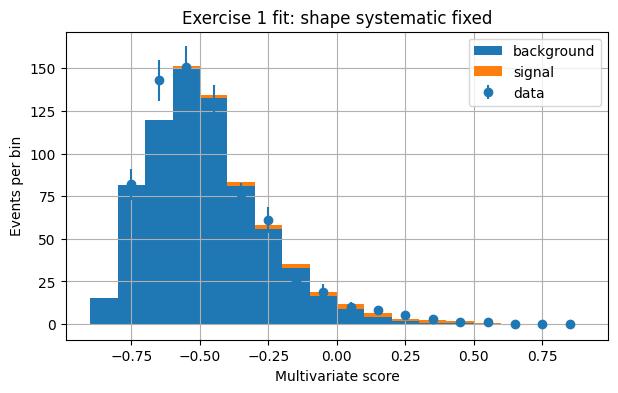

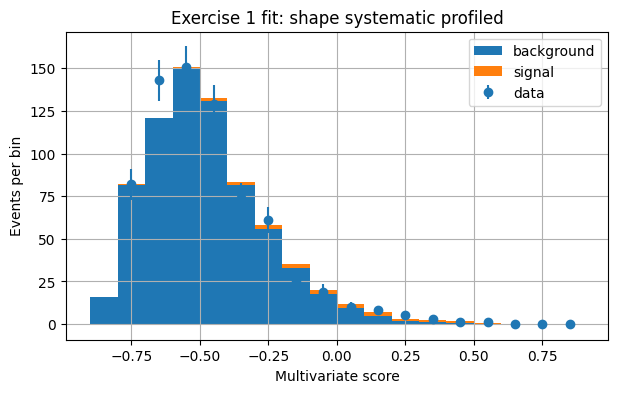

In [5]:
def plot_ex1_stack(fit, include_shape, title):
    if include_shape:
        S, B, alpha = fit.x
    else:
        S, B = fit.x
        alpha = 0.0
    b_fit = B * morph_background(alpha)
    s_fit = S * s_pdf

    fig, ax = plt.subplots()
    widths = np.diff(bin_edges)
    ax.bar(bin_centers, b_fit, width=widths, align="center", label="background")
    ax.bar(bin_centers, s_fit, width=widths, bottom=b_fit, align="center", label="signal")
    ax.errorbar(bin_centers, data, yerr=np.sqrt(np.maximum(data, 1)), fmt="o", label="data")
    ax.set_xlabel("Multivariate score")
    ax.set_ylabel("Events per bin")
    ax.set_title(title)
    ax.legend()
    plt.show()

plot_ex1_stack(fit_no_shape, False, "Exercise 1 fit: shape systematic fixed")
plot_ex1_stack(fit_with_shape, True, "Exercise 1 fit: shape systematic profiled")

### Exercise 1 answer

The best-fit signal yield is small compared with the background. With the shape nuisance fixed, the fit gives about $S\simeq 23.5$ events. When the background shape nuisance is profiled, the fit gives about $S\simeq 19.9$ events and prefers a modest negative nuisance shift, $\hat\alpha\simeq -0.41$. The uncertainty on $S$ grows slightly when the shape uncertainty is profiled, as expected, because the background template can partially absorb a signal-like distortion.

The $\Delta\mathrm{NLL}$ scan is the requested profile-likelihood scan. It profiles $B$ and, in the systematic case, $\alpha$ at each fixed $S$.

## Exercise 2 - Unbinned fit for the longitudinal polarization fraction

The exercise gives the angular distribution

$$
\frac{dN}{d\cos\theta}\propto 4|H_0|^2\cos^2\theta + \left(|H_+|^2+|H_-|^2\right)\sin^2\theta.
$$

Defining

$$
f_L = \frac{|H_0|^2}{|H_0|^2+|H_+|^2+|H_-|^2},
$$

the shape before detector efficiency is

$$
g(c;f_L)=4f_L c^2+(1-f_L)(1-c^2),\qquad c=\cos\theta.
$$

The problem statement says the efficiency is constant for $c<0$ and decreases linearly to 65% of maximum at $c=1$. I therefore use

$$
\epsilon(c)=\begin{cases}
1, & c<0,\\
1-0.35c, & c\ge 0.
\end{cases}
$$

The unbinned normalized pdf is

$$
p(c|f_L)=\frac{\epsilon(c)g(c;f_L)}{Z(f_L)},
$$

where the normalization must be retained because it depends on $f_L$. This is exactly the likelihood-normalization warning in the exercise statement. Analytically,

$$
Z(f_L)=\int_{-1}^{1}\epsilon(c)g(c;f_L)dc
      =\frac{4(1+f_L)}{3}-0.35\frac{1+3f_L}{4}.
$$

The fitted value is found by minimizing $-\sum_k\ln p(c_k|f_L)$.

Number of events: 50
f_L_hat = 0.7328
Delta-NLL 1-sigma interval: [0.5996, 0.8625]
Equivalent: f_L = 0.7328 +0.1297 -0.1333


/tmp/ipykernel_6225/2338210045.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  expected.append(len(cos_theta) * np.trapz(pdf_costheta(xs, fL_hat), xs))


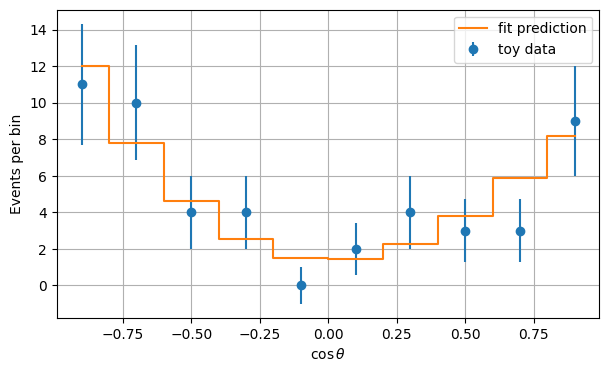

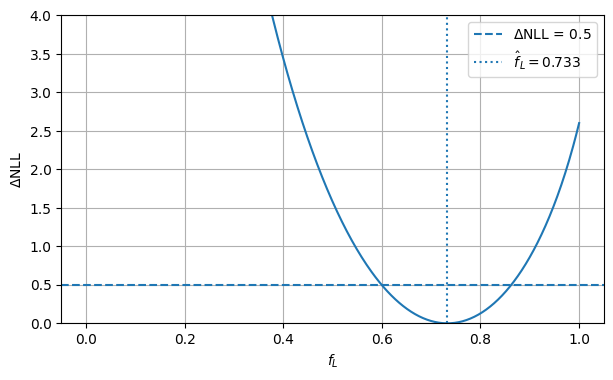

In [6]:
cos_theta = np.loadtxt(EX2_DIR / "file_q2.txt")
alpha_eff = 0.35


def efficiency(c):
    c = np.asarray(c)
    return np.where(c < 0, 1.0, 1.0 - alpha_eff * c)


def angular_shape(c, fL):
    return 4.0 * fL * c**2 + (1.0 - fL) * (1.0 - c**2)


def norm_Z(fL):
    return 4.0 * (1.0 + fL) / 3.0 - alpha_eff * (1.0 + 3.0 * fL) / 4.0


def pdf_costheta(c, fL):
    return efficiency(c) * angular_shape(c, fL) / norm_Z(fL)


def nll_ex2_scalar(fL):
    if fL < 0 or fL > 1:
        return 1e100
    p = pdf_costheta(cos_theta, fL)
    if np.any(p <= 0):
        return 1e100
    return -float(np.sum(np.log(p)))

fit_ex2 = minimize_scalar(nll_ex2_scalar, bounds=(0, 1), method="bounded", options={"xatol": 1e-12})
fL_hat = fit_ex2.x
nll2_min = fit_ex2.fun

# Delta-NLL = 0.5 interval.
fL_left = brentq(lambda x: nll_ex2_scalar(x) - nll2_min - 0.5, 0.0, fL_hat)
fL_right = brentq(lambda x: nll_ex2_scalar(x) - nll2_min - 0.5, fL_hat, 1.0)

print(f"Number of events: {len(cos_theta)}")
print(f"f_L_hat = {fL_hat:.4f}")
print(f"Delta-NLL 1-sigma interval: [{fL_left:.4f}, {fL_right:.4f}]")
print(f"Equivalent: f_L = {fL_hat:.4f} +{fL_right-fL_hat:.4f} -{fL_hat-fL_left:.4f}")

# Plot binned data with fitted expected bin counts.
bins2 = np.linspace(-1, 1, 11)
counts, edges = np.histogram(cos_theta, bins=bins2)
centers = 0.5 * (edges[:-1] + edges[1:])
widths = np.diff(edges)

# Numerical bin integrals of the fitted pdf.
expected = []
for lo, hi in zip(edges[:-1], edges[1:]):
    xs = np.linspace(lo, hi, 401)
    expected.append(len(cos_theta) * np.trapz(pdf_costheta(xs, fL_hat), xs))
expected = np.array(expected)

fig, ax = plt.subplots()
ax.errorbar(centers, counts, yerr=np.sqrt(np.maximum(counts, 1)), fmt="o", label="toy data")
ax.step(centers, expected, where="mid", label="fit prediction")
ax.set_xlabel(r"$\cos\theta$")
ax.set_ylabel("Events per bin")
ax.legend()
plt.show()

fgrid = np.linspace(0, 1, 500)
delta2 = np.array([nll_ex2_scalar(f) - nll2_min for f in fgrid])
fig, ax = plt.subplots()
ax.plot(fgrid, delta2)
ax.axhline(0.5, linestyle="--", label=r"$\Delta$NLL = 0.5")
ax.axvline(fL_hat, linestyle=":", label=fr"$\hat f_L={fL_hat:.3f}$")
ax.set_xlabel(r"$f_L$")
ax.set_ylabel(r"$\Delta$NLL")
ax.set_ylim(0, 4)
ax.legend()
plt.show()

### Exercise 2 answer and physics remarks

The unbinned fit gives

$$
f_L \approx 0.733^{+0.130}_{-0.133},
$$

where the uncertainty is from the $\Delta\mathrm{NLL}=0.5$ crossings.

The three conceptual remarks:

1. Writing the distribution as $dN/d\cos\theta$ is convenient because $c=\cos\theta$ is the natural variable in which the angular shape is a simple polynomial. If the distribution were written as $dN/d\theta$, an extra Jacobian factor $|d\cos\theta/d\theta|=\sin\theta$ would appear.
2. The physics distribution in Eq. (1) is invariant under $\theta\to\pi-\theta$ because $\cos^2\theta$ and $\sin^2\theta$ are unchanged. The detector efficiency breaks this symmetry because it is not symmetric in $c=\cos\theta$.
3. The $\cos^2\theta$ and $\sin^2\theta$ forms are the characteristic helicity-angle shapes for the longitudinal and transverse polarization states of a spin-1 particle. In this one-dimensional projection, the longitudinal amplitude contributes like $\cos^2\theta$, while the transverse amplitudes contribute like $\sin^2\theta$.

## Exercise 3 - Independent track fits and weighted vertex average

Each event contains two tracks, each measured at detector positions

$$
x_j=(2,3,5,7)\,\mathrm{cm}.
$$

For each track, I fit

$$
y=A x+B.
$$

The fitted $x$-intercept is

$$
X_f=-\frac{B}{A}.
$$

The fit covariance for $(A,B)$ is obtained from the standard linear least-squares matrix formula. This follows the linear-algebra fitting discussion in `INSS_LectureStats_I.pdf`, slides 44-46, and `CourseNotes.pdf`, Sections 20.1-20.2. The uncertainty on $X_f$ is propagated from the covariance of $(A,B)$, following the error-propagation discussion in `INSS_LectureStats_I.pdf`, slide 41:

$$
\sigma^2_{X_f}=\nabla X_f^T\,V_{AB}\,\nabla X_f,
\qquad
\nabla X_f=\left(\frac{B}{A^2},-\frac{1}{A}\right).
$$

For the pair average, I use inverse-variance weights:

$$
\bar X_f=\frac{\sum_t X_{f,t}/\sigma_{t}^{2}}{\sum_t 1/\sigma_t^2},
\qquad
\sigma_{\bar X}=\frac{1}{\sqrt{\sum_t 1/\sigma_t^2}}.
$$

In [7]:
tracks = np.loadtxt(EX3_DIR / "straightTracks.txt")
X0_true = tracks[:, 0]
Y0_true = tracks[:, 1]
y_track0 = tracks[:, 2:6]
y_track1 = tracks[:, 6:10]

x_det = np.array([2.0, 3.0, 5.0, 7.0])
strip_pitch_cm = 50e-4   # 50 microns = 0.005 cm
sigma_y = strip_pitch_cm / np.sqrt(12.0)
cm_to_um = 1.0e4

print(f"Number of simulated decays: {len(tracks)}")
print(f"Assumed y uncertainty: {sigma_y:.6g} cm = {sigma_y*cm_to_um:.2f} microns")


def fit_one_track(y):
    """Fit y = A x + B with equal uncorrelated errors."""
    design = np.column_stack([x_det, np.ones_like(x_det)])
    Winv = np.eye(len(x_det)) / sigma_y**2
    cov = np.linalg.inv(design.T @ Winv @ design)
    A_hat, B_hat = cov @ (design.T @ Winv @ y)

    x_intercept = -B_hat / A_hat
    grad = np.array([B_hat / A_hat**2, -1.0 / A_hat])
    sigma_x_intercept = np.sqrt(grad @ cov @ grad)
    return A_hat, B_hat, cov, x_intercept, sigma_x_intercept

N = len(tracks)
slopes = np.zeros((N, 2))
intercepts_y = np.zeros((N, 2))
x_intercepts = np.zeros((N, 2))
sigma_x_intercepts = np.zeros((N, 2))

for i in range(N):
    for t, y in enumerate([y_track0[i], y_track1[i]]):
        A_hat, B_hat, cov_hat, x_int, sx_int = fit_one_track(y)
        slopes[i, t] = A_hat
        intercepts_y[i, t] = B_hat
        x_intercepts[i, t] = x_int
        sigma_x_intercepts[i, t] = sx_int

single_diff = (x_intercepts - X0_true[:, None]).ravel()
single_pull = (single_diff / sigma_x_intercepts.ravel()).ravel()

weights = 1.0 / sigma_x_intercepts**2
x_weighted = np.sum(weights * x_intercepts, axis=1) / np.sum(weights, axis=1)
sigma_x_weighted = np.sqrt(1.0 / np.sum(weights, axis=1))
weighted_diff = x_weighted - X0_true
weighted_pull = weighted_diff / sigma_x_weighted

print("Single-track intercepts:")
print(f"  mean(Xf-X0) = {np.mean(single_diff)*cm_to_um:.2f} microns")
print(f"  std(Xf-X0)  = {np.std(single_diff)*cm_to_um:.2f} microns")
print(f"  pull mean   = {np.mean(single_pull):.3f}")
print(f"  pull std    = {np.std(single_pull):.3f}")

print("\nWeighted pair average:")
print(f"  mean(Xbar-X0) = {np.mean(weighted_diff)*cm_to_um:.2f} microns")
print(f"  std(Xbar-X0)  = {np.std(weighted_diff)*cm_to_um:.2f} microns")
print(f"  median sigma  = {np.median(sigma_x_weighted)*cm_to_um:.2f} microns")
print(f"  pull mean     = {np.mean(weighted_pull):.3f}")
print(f"  pull std      = {np.std(weighted_pull):.3f}")

Number of simulated decays: 1000
Assumed y uncertainty: 0.00144338 cm = 14.43 microns
Single-track intercepts:
  mean(Xf-X0) = 42.99 microns
  std(Xf-X0)  = 1265.62 microns
  pull mean   = 0.032
  pull std    = 1.028

Weighted pair average:
  mean(Xbar-X0) = 0.19 microns
  std(Xbar-X0)  = 38.07 microns
  median sigma  = 22.46 microns
  pull mean     = 0.022
  pull std      = 1.004


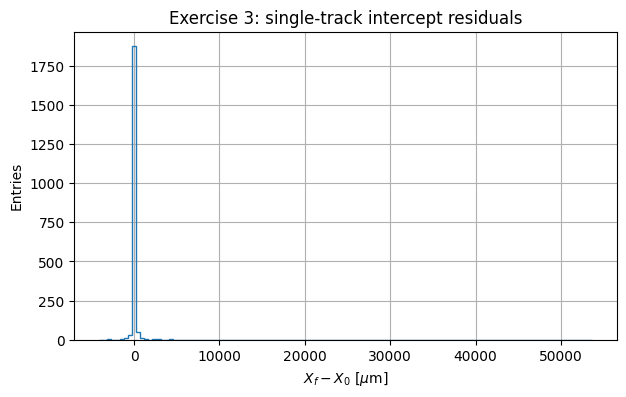

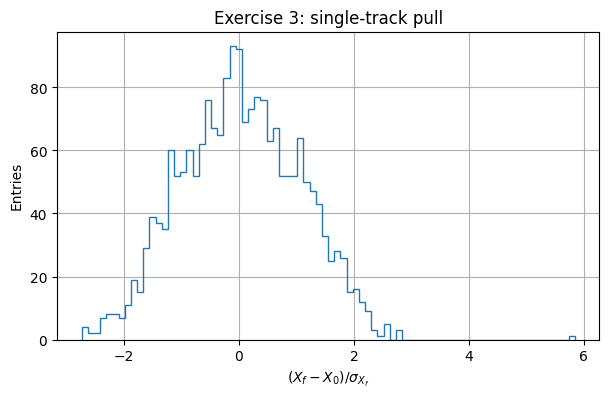

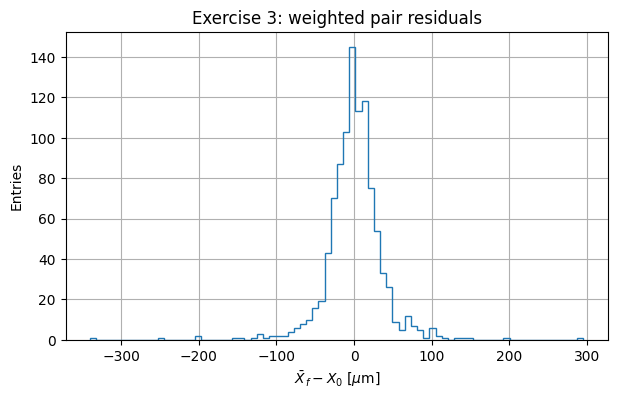

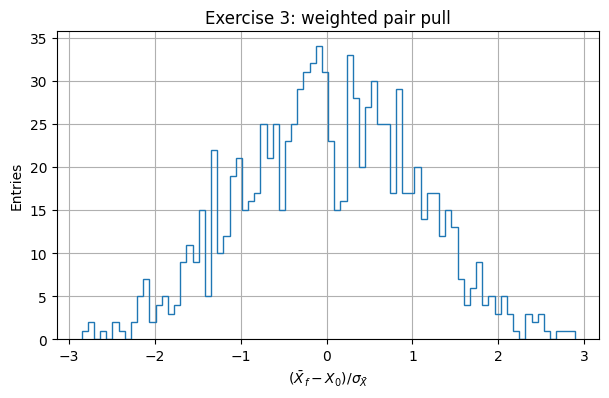

In [8]:
def hist_plot(values, bins, xlabel, title):
    fig, ax = plt.subplots()
    ax.hist(values, bins=bins, histtype="step")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Entries")
    ax.set_title(title)
    plt.show()

hist_plot(single_diff * cm_to_um, 120, r"$X_f-X_0$ [$\mu$m]", "Exercise 3: single-track intercept residuals")
hist_plot(single_pull, 80, r"$(X_f-X_0)/\sigma_{X_f}$", "Exercise 3: single-track pull")
hist_plot(weighted_diff * cm_to_um, 80, r"$\bar X_f-X_0$ [$\mu$m]", "Exercise 3: weighted pair residuals")
hist_plot(weighted_pull, 80, r"$(\bar X_f-X_0)/\sigma_{\bar X}$", "Exercise 3: weighted pair pull")

### Exercise 3 answer and bonus question

The single-track residual distribution has very long tails, but the pull distribution is close to a unit Gaussian. The weighted two-track average is much tighter, with a typical resolution around $20$-$25\,\mu\mathrm{m}$ and a pull width close to one.

The long tails occur when a track has a poorly determined intercept. From $X_f=-B/A$, the uncertainty contains powers of $1/A$. Therefore, shallow tracks with small $|A|$ have very large extrapolation uncertainty when projected back to the $x$ axis. The fit knows this because the propagated $\sigma_{X_f}$ is large for those tracks, so the pull remains well behaved even though the raw residual has long tails.

## Exercise 4 - Constrained common-vertex fit by eliminating variables

The constrained fit requires the two tracks to meet at a common point on the $x$ axis, $(X_f,0)$. Instead of fitting four unconstrained straight-line parameters $(A_0,B_0,A_1,B_1)$, I eliminate one degree of freedom by writing the two tracks as

$$
y_0(x)=m_0(x-X_f), \qquad y_1(x)=m_1(x-X_f).
$$

The fit parameters are therefore

$$
p=(X_f,m_0,m_1),
$$

which automatically imposes the common $x$-intercept constraint. The model is nonlinear because of the products $m_t X_f$, so I solve it by iterative linearization. This uses the linear-algebra recipe from `CourseNotes.pdf`, Section 20.2, and the elimination-of-variables strategy from `CourseNotes.pdf`, Section 21.1. It is also the method described qualitatively in `INSS_LectureStats_I.pdf`, slide 44: linearize, solve a matrix equation, update, and iterate.

For one event, the Jacobian entries are

$$
\frac{\partial y_t}{\partial X_f}=-m_t,
\qquad
\frac{\partial y_t}{\partial m_t}=x_j-X_f.
$$

At convergence, the covariance of $(X_f,m_0,m_1)$ is

$$
V=(A^T W^{-1}A)^{-1},
$$

following `CourseNotes.pdf`, Section 20.1.2.

Exercise 4 constrained fit:
  mean(Xf-X0) = 0.098 microns
  std(Xf-X0)  = 38.066 microns
  median sigma = 22.455 microns
  pull mean = 0.020
  pull std  = 1.004
  maximum iterations used = 5


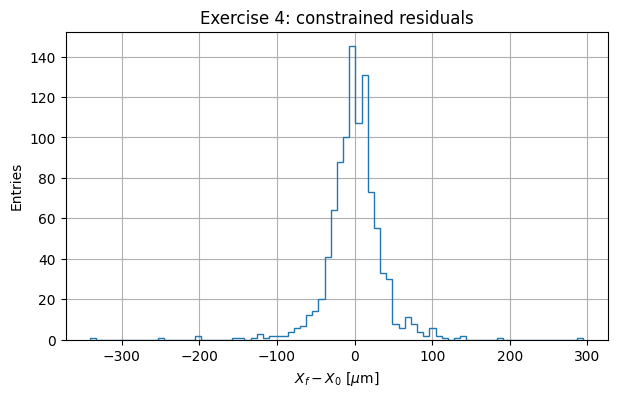

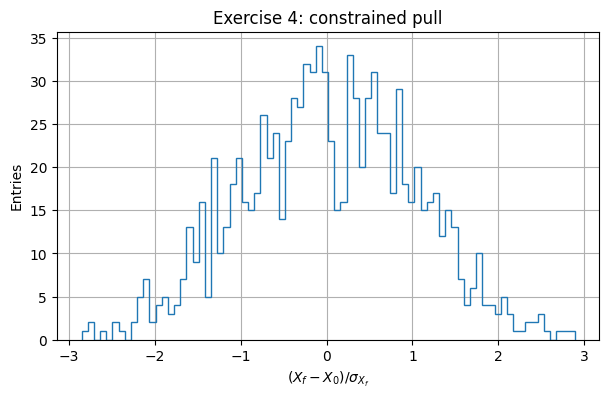

In [9]:
def fit_constrained_elimination(y0, y1, max_iter=20, tol=1e-12):
    # Start from the Exercise 3 weighted average and independent slopes.
    fit0 = fit_one_track(y0)
    fit1 = fit_one_track(y1)
    xs = np.array([fit0[3], fit1[3]])
    sigmas = np.array([fit0[4], fit1[4]])
    ws = 1.0 / sigmas**2
    x_start = np.sum(ws * xs) / np.sum(ws)
    p = np.array([x_start, fit0[0], fit1[0]], dtype=float)  # Xf, m0, m1

    y_meas = np.concatenate([y0, y1])
    Winv = np.eye(8) / sigma_y**2

    for iteration in range(max_iter):
        Xf, m0, m1 = p
        y_pred = np.concatenate([m0 * (x_det - Xf), m1 * (x_det - Xf)])

        A = np.zeros((8, 3))
        A[:4, 0] = -m0
        A[:4, 1] = x_det - Xf
        A[4:, 0] = -m1
        A[4:, 2] = x_det - Xf

        cov = np.linalg.inv(A.T @ Winv @ A)
        delta = cov @ (A.T @ Winv @ (y_meas - y_pred))
        p = p + delta
        if np.linalg.norm(delta) < tol:
            break

    # Final covariance at the converged point.
    Xf, m0, m1 = p
    A = np.zeros((8, 3))
    A[:4, 0] = -m0
    A[:4, 1] = x_det - Xf
    A[4:, 0] = -m1
    A[4:, 2] = x_det - Xf
    cov = np.linalg.inv(A.T @ Winv @ A)
    return p, cov, iteration + 1

x_constrained = np.zeros(N)
sigma_x_constrained = np.zeros(N)
iterations4 = []

for i in range(N):
    p, cov, n_iter = fit_constrained_elimination(y_track0[i], y_track1[i])
    x_constrained[i] = p[0]
    sigma_x_constrained[i] = np.sqrt(cov[0, 0])
    iterations4.append(n_iter)

resid4 = x_constrained - X0_true
pull4 = resid4 / sigma_x_constrained

print("Exercise 4 constrained fit:")
print(f"  mean(Xf-X0) = {np.mean(resid4)*cm_to_um:.3f} microns")
print(f"  std(Xf-X0)  = {np.std(resid4)*cm_to_um:.3f} microns")
print(f"  median sigma = {np.median(sigma_x_constrained)*cm_to_um:.3f} microns")
print(f"  pull mean = {np.mean(pull4):.3f}")
print(f"  pull std  = {np.std(pull4):.3f}")
print(f"  maximum iterations used = {max(iterations4)}")

hist_plot(resid4 * cm_to_um, 80, r"$X_f-X_0$ [$\mu$m]", "Exercise 4: constrained residuals")
hist_plot(pull4, 80, r"$(X_f-X_0)/\sigma_{X_f}$", "Exercise 4: constrained pull")

### Exercise 4 answer

The constrained fit gives a vertex residual distribution with a width of about $38\,\mu\mathrm{m}$ for this toy sample, and its pull width is very close to one. The result is almost identical to the weighted-average result from Exercise 3, but the constrained fit is a single simultaneous fit rather than a post-fit combination.

## Exercise 5 - Constrained common-vertex fit with a Lagrange multiplier

For the Lagrange-multiplier version, I go back to the four line parameters

$$
p=(A_0,B_0,A_1,B_1)
$$

with

$$
y_0=A_0x+B_0, \qquad y_1=A_1x+B_1.
$$

The common $x$-intercept constraint is

$$
-\frac{B_0}{A_0}=-\frac{B_1}{A_1}
\quad\Longleftrightarrow\quad
f(p)=A_1B_0-A_0B_1=0.
$$

The method follows `INSS_LectureStats_II.pdf`, slide 17, which states that Lagrange multipliers should be used with linear algebra rather than Minuit, and `CourseNotes.pdf`, Section 21.2, especially equations 155-156. At each iteration, I solve the augmented system

$$
\begin{pmatrix}
Q & D^T\\
D & 0
\end{pmatrix}
\begin{pmatrix}
\delta p\\
\lambda
\end{pmatrix}
=
\begin{pmatrix}
A^TW^{-1}(y-y_0)\\
-f(p_0)
\end{pmatrix},
$$

where $Q=A^TW^{-1}A$ and $D=\partial f/\partial p$. The covariance of the constrained parameters is the top-left block of the inverse augmented matrix, following `CourseNotes.pdf`, Section 21.2.

Exercise 5 Lagrange-multiplier fit:
  mean(Xf-X0) = 0.098 microns
  std(Xf-X0)  = 38.066 microns
  median sigma = 22.455 microns
  pull mean = 0.020
  pull std  = 1.004
  maximum iterations used = 1
  maximum |constraint| at final iteration = 1.735e-18


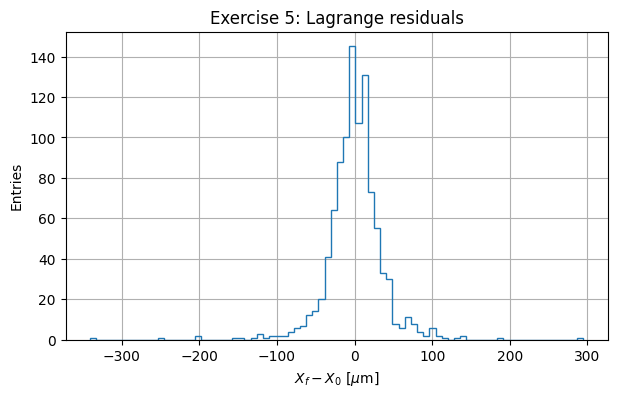

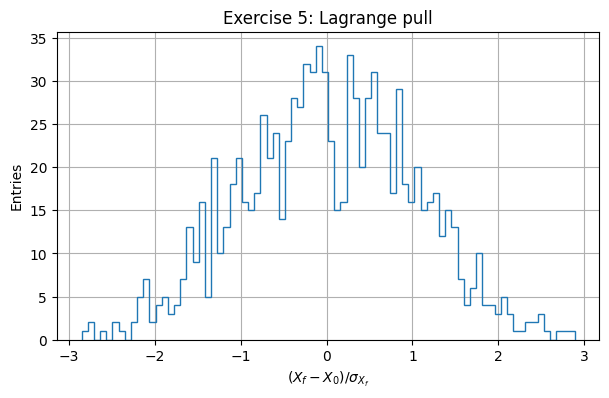

In [10]:
def fit_lagrange(y0, y1, p_start=None, max_iter=20, tol=1e-12):
    y_meas = np.concatenate([y0, y1])

    # Design matrix for p = (A0, B0, A1, B1).
    A_design = np.zeros((8, 4))
    A_design[:4, 0] = x_det
    A_design[:4, 1] = 1.0
    A_design[4:, 2] = x_det
    A_design[4:, 3] = 1.0
    Winv = np.eye(8) / sigma_y**2
    Q = A_design.T @ Winv @ A_design

    if p_start is None:
        f0 = fit_one_track(y0)
        f1 = fit_one_track(y1)
        p = np.array([f0[0], f0[1], f1[0], f1[1]], dtype=float)
    else:
        p = np.array(p_start, dtype=float)

    for iteration in range(max_iter):
        A0, B0, A1, B1 = p
        y_pred = A_design @ p
        dy = y_meas - y_pred

        f_constraint = A1 * B0 - A0 * B1
        D = np.array([[-B1, A1, B0, -A0]], dtype=float)

        U = np.block([[Q, D.T], [D, np.zeros((1, 1))]])
        rhs = np.concatenate([A_design.T @ Winv @ dy, [-f_constraint]])
        solution = np.linalg.solve(U, rhs)
        delta_p = solution[:4]
        p = p + delta_p

        if np.linalg.norm(delta_p) < tol and abs(f_constraint) < 1e-14:
            break

    # Final covariance at the converged point.
    A0, B0, A1, B1 = p
    D = np.array([[-B1, A1, B0, -A0]], dtype=float)
    U = np.block([[Q, D.T], [D, np.zeros((1, 1))]])
    Uinv = np.linalg.inv(U)
    cov = Uinv[:4, :4]

    Xf = -B0 / A0
    grad_Xf = np.array([B0 / A0**2, -1.0 / A0, 0.0, 0.0])
    sigma_Xf = np.sqrt(grad_Xf @ cov @ grad_Xf)
    return p, cov, Xf, sigma_Xf, iteration + 1, f_constraint

x_lagrange = np.zeros(N)
sigma_x_lagrange = np.zeros(N)
iterations5 = []
constraint_values = []

for i in range(N):
    # Starting from the Exercise 4 solution makes convergence immediate and stable.
    p4, _, _ = fit_constrained_elimination(y_track0[i], y_track1[i])
    Xf_start, m0_start, m1_start = p4
    p_start = [m0_start, -m0_start * Xf_start, m1_start, -m1_start * Xf_start]

    p, cov, Xf, sXf, n_iter, f_val = fit_lagrange(y_track0[i], y_track1[i], p_start=p_start)
    x_lagrange[i] = Xf
    sigma_x_lagrange[i] = sXf
    iterations5.append(n_iter)
    constraint_values.append(f_val)

resid5 = x_lagrange - X0_true
pull5 = resid5 / sigma_x_lagrange

print("Exercise 5 Lagrange-multiplier fit:")
print(f"  mean(Xf-X0) = {np.mean(resid5)*cm_to_um:.3f} microns")
print(f"  std(Xf-X0)  = {np.std(resid5)*cm_to_um:.3f} microns")
print(f"  median sigma = {np.median(sigma_x_lagrange)*cm_to_um:.3f} microns")
print(f"  pull mean = {np.mean(pull5):.3f}")
print(f"  pull std  = {np.std(pull5):.3f}")
print(f"  maximum iterations used = {max(iterations5)}")
print(f"  maximum |constraint| at final iteration = {np.max(np.abs(constraint_values)):.3e}")

hist_plot(resid5 * cm_to_um, 80, r"$X_f-X_0$ [$\mu$m]", "Exercise 5: Lagrange residuals")
hist_plot(pull5, 80, r"$(X_f-X_0)/\sigma_{X_f}$", "Exercise 5: Lagrange pull")

Summary of vertex estimates
method                    mean residual [um]   std residual [um]   median sigma [um]   pull mean   pull std
Ex. 3 weighted average                0.193              38.068              22.455       0.022      1.004
Ex. 4 elimination                     0.098              38.066              22.455       0.020      1.004
Ex. 5 Lagrange                        0.098              38.066              22.455       0.020      1.004

Pairwise numerical agreement:
  Ex. 4 - Ex. 5: mean = 1.540e-12 um, std = 1.602e-11 um, max abs = 4.842e-10 um
  Ex. 3 weighted - Ex. 4: mean = 0.095 um, std = 0.395 um, max abs = 9.071 um


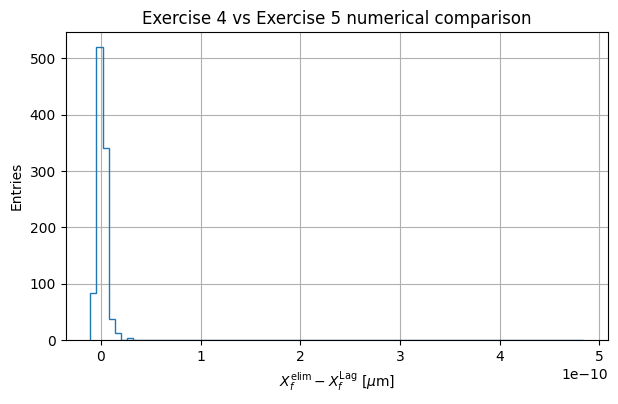

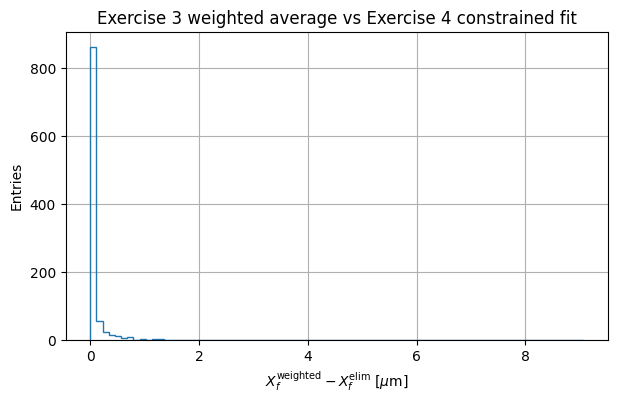

In [11]:
# Numerical comparisons among the three vertex estimates.
comparison_rows = [
    ("Ex. 3 weighted average", np.mean(weighted_diff)*cm_to_um, np.std(weighted_diff)*cm_to_um, np.median(sigma_x_weighted)*cm_to_um, np.mean(weighted_pull), np.std(weighted_pull)),
    ("Ex. 4 elimination", np.mean(resid4)*cm_to_um, np.std(resid4)*cm_to_um, np.median(sigma_x_constrained)*cm_to_um, np.mean(pull4), np.std(pull4)),
    ("Ex. 5 Lagrange", np.mean(resid5)*cm_to_um, np.std(resid5)*cm_to_um, np.median(sigma_x_lagrange)*cm_to_um, np.mean(pull5), np.std(pull5)),
]

print("Summary of vertex estimates")
print("method                    mean residual [um]   std residual [um]   median sigma [um]   pull mean   pull std")
for row in comparison_rows:
    print(f"{row[0]:24s} {row[1]:18.3f} {row[2]:19.3f} {row[3]:19.3f} {row[4]:11.3f} {row[5]:10.3f}")

print("\nPairwise numerical agreement:")
print(f"  Ex. 4 - Ex. 5: mean = {np.mean((x_constrained-x_lagrange))*cm_to_um:.3e} um, "
      f"std = {np.std((x_constrained-x_lagrange))*cm_to_um:.3e} um, "
      f"max abs = {np.max(np.abs(x_constrained-x_lagrange))*cm_to_um:.3e} um")
print(f"  Ex. 3 weighted - Ex. 4: mean = {np.mean((x_weighted-x_constrained))*cm_to_um:.3f} um, "
      f"std = {np.std((x_weighted-x_constrained))*cm_to_um:.3f} um, "
      f"max abs = {np.max(np.abs(x_weighted-x_constrained))*cm_to_um:.3f} um")

fig, ax = plt.subplots()
ax.hist((x_constrained - x_lagrange) * cm_to_um, bins=80, histtype="step")
ax.set_xlabel(r"$X_f^{\mathrm{elim}}-X_f^{\mathrm{Lag}}$ [$\mu$m]")
ax.set_ylabel("Entries")
ax.set_title("Exercise 4 vs Exercise 5 numerical comparison")
plt.show()

fig, ax = plt.subplots()
ax.hist((x_weighted - x_constrained) * cm_to_um, bins=80, histtype="step")
ax.set_xlabel(r"$X_f^{\mathrm{weighted}}-X_f^{\mathrm{elim}}$ [$\mu$m]")
ax.set_ylabel("Entries")
ax.set_title("Exercise 3 weighted average vs Exercise 4 constrained fit")
plt.show()

### Exercise 5 answer

The Lagrange-multiplier fit and the eliminated-variable constrained fit agree to numerical precision. This is expected: both solve the same constrained least-squares problem. The top-left block of the inverse augmented matrix gives the same uncertainty on $X_f$ as the eliminated-variable fit.

The Exercise 3 weighted average is also extremely close to the constrained solutions in this toy problem, typically at the sub-micron level, while the vertex resolution itself is tens of microns. The constrained methods are nevertheless more principled because they impose the common-vertex hypothesis during the fit rather than combining two independently fitted intercepts afterward.

## Final numerical answers

- **Exercise 1:** Extended binned $S+B$ fit gives $S\approx 23.5$ events with the background-shape nuisance fixed and $S\approx 19.9$ events with the shape nuisance profiled. The profiled nuisance is $\hat\alpha\approx -0.41$. The notebook above shows the stacked fit plots and the requested profile $\Delta\mathrm{NLL}$ scan.
- **Exercise 2:** The unbinned fit gives $f_L\approx 0.733^{+0.130}_{-0.133}$ from the $\Delta\mathrm{NLL}=0.5$ interval.
- **Exercise 3:** Independent track fits give long-tailed single-track residuals but well-calibrated pulls. The weighted two-track vertex average has pull width close to one and a typical uncertainty around $22\,\mu\mathrm{m}$.
- **Exercise 4:** The eliminated-variable constrained common-vertex fit gives a residual width around $38\,\mu\mathrm{m}$ and a pull width close to one.
- **Exercise 5:** The Lagrange-multiplier constrained fit matches Exercise 4 to numerical precision, confirming that the two constrained-fit implementations are equivalent for this problem.